# CIFAR-10 데이터셋을 활용한 PyTorch 딥러닝 분류 실습

CIFAR-10 이미지 데이터셋을 불러온 뒤, 이미지를 1차원 벡터로 펼쳐서 완전연결 신경망(MLP, Multi-Layer Perceptron)에 입력하고, 총 10개 클래스 중 하나로 분류하는 구조입니다.

CIFAR-10 데이터셋은 32×32 크기의 컬러 이미지로 구성되어 있으며, 각 이미지는 RGB 3개 채널을 가지므로 한 장의 이미지는 `32 × 32 × 3 = 3072`개의 숫자 데이터로 표현됩니다. 이 실습에서는 CNN이 아니라 Dense 층에 해당하는 PyTorch의 `nn.Linear` 계층을 사용하여 기본적인 다층 퍼셉트론 분류 모델을 구성합니다.

학습 과정은 다음 순서로 진행됩니다.

1. 필요한 PyTorch 관련 모듈을 불러옵니다.
2. CIFAR-10 데이터를 다운로드하고 훈련/검증/테스트 데이터셋으로 분리합니다.
3. 이미지를 0~1 범위로 정규화하고, MLP 입력에 맞게 1차원 벡터로 펼칩니다.
4. `nn.Module`을 상속하여 다층 신경망 모델을 정의합니다.
5. 손실 함수와 옵티마이저를 설정합니다.
6. 미니배치 단위로 모델을 학습하고 검증합니다.
7. 학습 결과를 그래프로 시각화합니다.
8. 테스트 데이터셋으로 최종 정확도를 평가합니다.

> 참고: CIFAR-10은 이미지의 배경, 색상, 모양 변화가 MNIST보다 훨씬 복잡합니다. 따라서 단순 MLP만으로는 CNN보다 정확도가 낮을 수 있습니다.

In [1]:
# PyTorch의 핵심 기능을 사용하기 위해 torch 모듈을 불러옵니다.
import torch

# torch.nn은 신경망 계층, 손실 함수 등 딥러닝 모델 구성에 필요한 클래스들을 제공합니다.
import torch.nn as nn

# torch.optim은 Adam, SGD와 같은 최적화 알고리즘을 제공합니다.
import torch.optim as optim

# DataLoader는 데이터를 미니배치 단위로 나누어 모델에 공급하는 도구입니다.
from torch.utils.data import DataLoader, random_split

# torchvision.datasets는 CIFAR-10, MNIST와 같은 공개 이미지 데이터셋을 쉽게 불러올 수 있게 해줍니다.
from torchvision import datasets

# torchvision.transforms는 이미지 데이터를 텐서로 바꾸거나 정규화하는 전처리 기능을 제공합니다.
from torchvision import transforms

# NumPy는 수치 계산과 배열 처리를 위해 사용합니다.
import numpy as np

# matplotlib.pyplot은 학습 결과 그래프를 시각화하기 위해 사용합니다.
import matplotlib.pyplot as plt

# random_split 결과가 매번 동일하게 나오도록 난수 시드를 고정합니다.
torch.manual_seed(42)

# GPU가 사용 가능하면 cuda를 사용하고, 그렇지 않으면 CPU를 사용하도록 장치를 설정합니다.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 현재 학습에 사용할 장치가 CPU인지 GPU인지 출력합니다.
print('사용 장치:', device)


사용 장치: cpu


## 1. CIFAR-10 데이터셋 불러오기와 전처리

`cifar10.load_data()`로 데이터를 불러온 뒤, 훈련 데이터 50,000개 중 앞의 40,000개를 실제 훈련용으로 사용하고 뒤의 10,000개를 검증용으로 사용합니다. PyTorch에서는 `torchvision.datasets.CIFAR10`으로 데이터를 불러오고, `random_split`을 사용하여 훈련 데이터와 검증 데이터를 나눕니다.

CIFAR-10 이미지는 원래 0~255 범위의 픽셀값을 갖습니다. `transforms.ToTensor()`를 적용하면 이미지가 PyTorch 텐서로 변환되면서 자동으로 0~1 범위의 실수값으로 바뀝니다.

In [2]:
# 이미지를 PyTorch 텐서로 변환하는 전처리 작업을 정의합니다.
transform = transforms.Compose([
    # PIL 이미지 또는 NumPy 배열 형태의 이미지를 torch.Tensor 형태로 변환합니다.
    # 동시에 픽셀값 범위를 0~255에서 0.0~1.0 사이로 자동 변환합니다.
    transforms.ToTensor()
])

# CIFAR-10 훈련 데이터셋을 다운로드하고 불러옵니다.
# root는 데이터가 저장될 폴더이며, train=True는 훈련 데이터 50,000개를 의미합니다.
# download=True는 데이터가 없을 경우 자동으로 다운로드하라는 의미입니다.
train_full_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# CIFAR-10 테스트 데이터셋을 다운로드하고 불러옵니다.
# train=False는 테스트 데이터 10,000개를 의미합니다.
test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# 훈련 데이터 40,000개와 검증 데이터 10,000개로 나눕니다.
train_size = 40000

# 전체 훈련 데이터 50,000개 중 나머지 10,000개를 검증 데이터로 사용합니다.
val_size = len(train_full_dataset) - train_size

# random_split을 사용해 전체 훈련 데이터를 훈련용과 검증용으로 분리합니다.
# generator에 시드를 지정하여 실행할 때마다 같은 방식으로 분리되도록 합니다.
train_dataset, val_dataset = random_split(
    train_full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# 미니배치 크기를 50으로 설정합니다.
batch_size = 50

# 훈련 데이터 로더를 생성합니다.
# shuffle=True는 매 epoch마다 데이터 순서를 섞어 모델이 순서에 과하게 의존하지 않도록 합니다.
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

# 검증 데이터 로더를 생성합니다.
# 검증 데이터는 성능 확인용이므로 일반적으로 shuffle=False로 둡니다.
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

# 테스트 데이터 로더를 생성합니다.
# 테스트 데이터도 최종 평가용이므로 shuffle=False로 둡니다.
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

# CIFAR-10의 클래스 이름을 저장합니다.
# 모델은 숫자 라벨 0~9를 예측하지만, 사람이 이해하기 쉽게 클래스 이름을 함께 둡니다.
class_names = train_full_dataset.classes

# 훈련, 검증, 테스트 데이터 개수를 출력하여 분리가 제대로 되었는지 확인합니다.
print('훈련 데이터 개수:', len(train_dataset))
print('검증 데이터 개수:', len(val_dataset))
print('테스트 데이터 개수:', len(test_dataset))
print('클래스 이름:', class_names)


100%|██████████| 170M/170M [00:03<00:00, 47.6MB/s]


훈련 데이터 개수: 40000
검증 데이터 개수: 10000
테스트 데이터 개수: 10000
클래스 이름: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 2. CIFAR-10 이미지 구조 확인

CIFAR-10의 각 이미지는 `3 × 32 × 32` 형태입니다. PyTorch에서는 이미지 텐서를 일반적으로 `(채널, 높이, 너비)` 순서로 저장합니다. 즉, 컬러 이미지이므로 채널이 3개이고, 가로와 세로 크기는 각각 32입니다.

 PyTorch 모델에서 `x.view(x.size(0), -1)`을 사용하여 미니배치 안의 각 이미지를 3072개의 입력값으로 펼칩니다.

In [3]:
# train_loader에서 첫 번째 미니배치 하나를 꺼냅니다.
images, labels = next(iter(train_loader))

# images의 형태를 출력합니다.
# 출력 예: torch.Size([50, 3, 32, 32])
# 50은 배치 크기, 3은 RGB 채널, 32와 32는 이미지의 높이와 너비입니다.
print('이미지 배치 형태:', images.shape)

# labels의 형태를 출력합니다.
# 출력 예: torch.Size([50])이며, 각 이미지의 정답 클래스 번호가 들어 있습니다.
print('라벨 배치 형태:', labels.shape)

# 첫 번째 이미지의 정답 숫자 라벨을 확인합니다.
print('첫 번째 이미지 라벨 번호:', labels[0].item())

# 첫 번째 이미지의 실제 클래스 이름을 확인합니다.
print('첫 번째 이미지 클래스 이름:', class_names[labels[0].item()])


이미지 배치 형태: torch.Size([50, 3, 32, 32])
라벨 배치 형태: torch.Size([50])
첫 번째 이미지 라벨 번호: 3
첫 번째 이미지 클래스 이름: cat


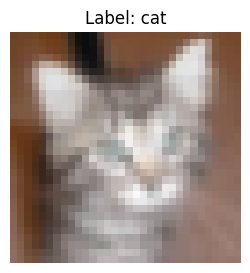

In [4]:
# 시각화를 위해 첫 번째 이미지 텐서를 선택합니다.
sample_image = images[0]

# PyTorch 이미지 형태는 [채널, 높이, 너비]이므로 matplotlib에서 출력하기 위해 [높이, 너비, 채널] 형태로 바꿉니다.
sample_image_for_plot = sample_image.permute(1, 2, 0)

# 그림 크기를 설정합니다.
plt.figure(figsize=(3, 3))

# 첫 번째 이미지를 화면에 출력합니다.
plt.imshow(sample_image_for_plot)

# 이미지 제목으로 정답 클래스 이름을 표시합니다.
plt.title(f'Label: {class_names[labels[0].item()]}')

# 이미지 축 눈금은 학습 내용과 직접 관련이 없으므로 숨깁니다.
plt.axis('off')

# 시각화 결과를 출력합니다.
plt.show()


## 3. PyTorch MLP 모델 정의

다음 구조를 사용합니다.

- 입력 크기: `32 × 32 × 3 = 3072`
- 첫 번째 은닉층: 2500개 뉴런, ReLU
- 두 번째 은닉층: 1500개 뉴런, ReLU
- 세 번째 은닉층: 500개 뉴런, ReLU
- 출력층: 10개 뉴런, Softmax

PyTorch의 `nn.CrossEntropyLoss`는 내부적으로 Softmax 계산을 포함하므로, 모델의 마지막 출력층에는 Softmax를 직접 넣지 않습니다. 즉, 모델은 10개의 원시 점수(logits)를 출력하고, 손실 함수가 이 값을 이용하여 다중 분류 손실을 계산합니다.

In [5]:
# nn.Module을 상속하여 CIFAR-10 분류용 다층 퍼셉트론 모델 클래스를 정의합니다.
class CIFAR10MLP(nn.Module):
    # __init__ 메서드는 모델에 필요한 계층을 생성하는 초기화 함수입니다.
    def __init__(self):
        # 부모 클래스 nn.Module의 초기화 기능을 먼저 실행합니다.
        super(CIFAR10MLP, self).__init__()

        # 첫 번째 완전연결층입니다.
        # 입력은 32*32*3=3072개 픽셀값이고, 출력은 2500개 특징입니다.
        self.fc1 = nn.Linear(32 * 32 * 3, 2500)

        # 두 번째 완전연결층입니다.
        # 앞 층의 2500개 출력을 받아 1500개 특징으로 변환합니다.
        self.fc2 = nn.Linear(2500, 1500)

        # 세 번째 완전연결층입니다.
        # 앞 층의 1500개 출력을 받아 500개 특징으로 변환합니다.
        self.fc3 = nn.Linear(1500, 500)

        # 출력층입니다.
        # CIFAR-10은 클래스가 10개이므로 최종 출력도 10개입니다.
        self.fc4 = nn.Linear(500, 10)

        # ReLU 활성화 함수입니다.
        # 음수는 0으로 만들고 양수는 그대로 통과시켜 비선형성을 추가합니다.
        self.relu = nn.ReLU()

    # forward 메서드는 입력 데이터가 모델을 통과하는 순서를 정의합니다.
    def forward(self, x):
        # 입력 이미지 x의 원래 형태는 [배치크기, 3, 32, 32]입니다.
        # MLP는 1차원 벡터를 입력으로 받으므로 [배치크기, 3072] 형태로 펼칩니다.
        x = x.view(x.size(0), -1)

        # 첫 번째 완전연결층을 통과시킨 뒤 ReLU 활성화 함수를 적용합니다.
        x = self.relu(self.fc1(x))

        # 두 번째 완전연결층을 통과시킨 뒤 ReLU 활성화 함수를 적용합니다.
        x = self.relu(self.fc2(x))

        # 세 번째 완전연결층을 통과시킨 뒤 ReLU 활성화 함수를 적용합니다.
        x = self.relu(self.fc3(x))

        # 마지막 출력층을 통과시켜 클래스별 점수 10개를 생성합니다.
        # 여기서는 Softmax를 적용하지 않습니다.
        # nn.CrossEntropyLoss가 Softmax 역할을 내부적으로 함께 처리하기 때문입니다.
        x = self.fc4(x)

        # 최종적으로 각 클래스에 대한 원시 점수(logits)를 반환합니다.
        return x

# 정의한 모델 클래스로부터 실제 모델 객체를 생성합니다.
model = CIFAR10MLP()

# 모델을 CPU 또는 GPU 장치로 이동시킵니다.
model = model.to(device)

# 모델 구조를 출력하여 각 계층이 제대로 생성되었는지 확인합니다.
print(model)


CIFAR10MLP(
  (fc1): Linear(in_features=3072, out_features=2500, bias=True)
  (fc2): Linear(in_features=2500, out_features=1500, bias=True)
  (fc3): Linear(in_features=1500, out_features=500, bias=True)
  (fc4): Linear(in_features=500, out_features=10, bias=True)
  (relu): ReLU()
)


## 4. 손실 함수와 옵티마이저 설정

PyTorch에서는 다중 분류 문제에 `nn.CrossEntropyLoss()`를 사용합니다. 이 손실 함수는 정답 라벨을 One-Hot Encoding 형태가 아니라 정수 라벨 형태로 받습니다.

In [6]:
# 다중 분류 문제에서 사용하는 교차 엔트로피 손실 함수입니다.
# 모델 출력은 [배치크기, 클래스개수] 형태의 logits이고, 정답은 [배치크기] 형태의 정수 라벨입니다.
criterion = nn.CrossEntropyLoss()

# Adam 옵티마이저를 생성합니다.
# model.parameters()는 학습 가능한 모든 가중치와 편향을 옵티마이저에 전달합니다.
# lr은 learning rate, 즉 한 번에 가중치를 얼마나 크게 수정할지 결정하는 학습률입니다.
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 전체 학습 반복 횟수를 10으로 설정합니다.
epochs = 10


## 5. 학습 및 검증 함수 정의

PyTorch는 학습 반복문을 직접 작성해야 합니다.

학습 과정은 일반적으로 다음 순서로 진행됩니다.

1. 모델을 학습 모드로 전환합니다.
2. 미니배치 데이터를 장치로 이동합니다.
3. 모델 예측값을 계산합니다.
4. 손실값을 계산합니다.
5. 이전 기울기를 초기화합니다.
6. 역전파를 수행합니다.
7. 옵티마이저가 가중치를 갱신합니다.
8. 손실과 정확도를 기록합니다.

In [7]:
# 한 epoch 동안 훈련을 수행하는 함수를 정의합니다.
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    # 모델을 학습 모드로 전환합니다.
    # Dropout, BatchNorm 같은 계층이 있을 때 학습 방식으로 동작하게 합니다.
    model.train()

    # epoch 동안 누적된 손실값을 저장할 변수를 초기화합니다.
    running_loss = 0.0

    # 맞힌 데이터 개수를 저장할 변수를 초기화합니다.
    correct = 0

    # 전체 데이터 개수를 저장할 변수를 초기화합니다.
    total = 0

    # train_loader에서 미니배치 단위로 이미지와 라벨을 하나씩 꺼냅니다.
    for images, labels in train_loader:
        # 이미지 데이터를 CPU 또는 GPU 장치로 이동합니다.
        images = images.to(device)

        # 정답 라벨 데이터를 CPU 또는 GPU 장치로 이동합니다.
        labels = labels.to(device)

        # 이전 미니배치에서 계산된 기울기를 초기화합니다.
        # 이 작업을 하지 않으면 기울기가 계속 누적됩니다.
        optimizer.zero_grad()

        # 모델에 이미지를 입력하여 클래스별 예측 점수(logits)를 계산합니다.
        outputs = model(images)

        # 예측 점수와 실제 정답 라벨을 비교하여 손실값을 계산합니다.
        loss = criterion(outputs, labels)

        # 손실값을 기준으로 역전파를 수행하여 각 파라미터의 기울기를 계산합니다.
        loss.backward()

        # 계산된 기울기를 사용하여 모델의 가중치와 편향을 갱신합니다.
        optimizer.step()

        # 현재 미니배치의 손실값에 데이터 개수를 곱해 누적 손실에 더합니다.
        running_loss += loss.item() * images.size(0)

        # outputs에서 가장 큰 점수를 가진 클래스 번호를 예측 결과로 선택합니다.
        _, predicted = torch.max(outputs, 1)

        # 현재 미니배치의 전체 데이터 개수를 total에 누적합니다.
        total += labels.size(0)

        # 예측값과 정답이 같은 개수를 correct에 누적합니다.
        correct += (predicted == labels).sum().item()

    # epoch 평균 손실을 계산합니다.
    epoch_loss = running_loss / total

    # epoch 평균 정확도를 계산합니다.
    epoch_acc = correct / total

    # 계산된 평균 손실과 정확도를 반환합니다.
    return epoch_loss, epoch_acc

# 검증 또는 테스트를 수행하는 함수를 정의합니다.
def evaluate(model, data_loader, criterion, device):
    # 모델을 평가 모드로 전환합니다.
    # 학습이 아니라 평가이므로 일부 계층이 평가 방식으로 동작합니다.
    model.eval()

    # 평가 동안 누적된 손실값을 저장할 변수를 초기화합니다.
    running_loss = 0.0

    # 맞힌 데이터 개수를 저장할 변수를 초기화합니다.
    correct = 0

    # 전체 데이터 개수를 저장할 변수를 초기화합니다.
    total = 0

    # 평가 단계에서는 기울기를 계산할 필요가 없으므로 no_grad()를 사용합니다.
    # 이를 통해 메모리 사용량이 줄고 평가 속도가 빨라집니다.
    with torch.no_grad():
        # data_loader에서 미니배치 단위로 이미지와 라벨을 하나씩 꺼냅니다.
        for images, labels in data_loader:
            # 이미지 데이터를 CPU 또는 GPU 장치로 이동합니다.
            images = images.to(device)

            # 정답 라벨 데이터를 CPU 또는 GPU 장치로 이동합니다.
            labels = labels.to(device)

            # 모델에 이미지를 입력하여 클래스별 예측 점수(logits)를 계산합니다.
            outputs = model(images)

            # 예측 점수와 실제 정답 라벨을 비교하여 손실값을 계산합니다.
            loss = criterion(outputs, labels)

            # 현재 미니배치의 손실값에 데이터 개수를 곱해 누적 손실에 더합니다.
            running_loss += loss.item() * images.size(0)

            # outputs에서 가장 큰 점수를 가진 클래스 번호를 예측 결과로 선택합니다.
            _, predicted = torch.max(outputs, 1)

            # 현재 미니배치의 전체 데이터 개수를 total에 누적합니다.
            total += labels.size(0)

            # 예측값과 정답이 같은 개수를 correct에 누적합니다.
            correct += (predicted == labels).sum().item()

    # 전체 데이터 기준 평균 손실을 계산합니다.
    epoch_loss = running_loss / total

    # 전체 데이터 기준 평균 정확도를 계산합니다.
    epoch_acc = correct / total

    # 계산된 평균 손실과 정확도를 반환합니다.
    return epoch_loss, epoch_acc


## 6. 모델 학습 실행

아래 코드는 각 epoch마다 훈련 손실, 훈련 정확도, 검증 손실, 검증 정확도를 계산하여 리스트에 저장합니다. 저장된 값들은 나중에 그래프로 시각화합니다.

In [8]:
# epoch별 훈련 손실을 저장할 리스트를 생성합니다.
train_losses = []

# epoch별 검증 손실을 저장할 리스트를 생성합니다.
val_losses = []

# epoch별 훈련 정확도를 저장할 리스트를 생성합니다.
train_accuracies = []

# epoch별 검증 정확도를 저장할 리스트를 생성합니다.
val_accuracies = []

# 지정한 epoch 수만큼 학습을 반복합니다.
for epoch in range(epochs):
    # 한 epoch 동안 훈련 데이터를 사용하여 모델을 학습합니다.
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)

    # 한 epoch 학습 후 검증 데이터를 사용하여 모델 성능을 평가합니다.
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    # 훈련 손실을 리스트에 저장합니다.
    train_losses.append(train_loss)

    # 검증 손실을 리스트에 저장합니다.
    val_losses.append(val_loss)

    # 훈련 정확도를 리스트에 저장합니다.
    train_accuracies.append(train_acc)

    # 검증 정확도를 리스트에 저장합니다.
    val_accuracies.append(val_acc)

    # 현재 epoch의 학습 결과를 보기 좋게 출력합니다.
    print(
        f'Epoch [{epoch + 1}/{epochs}] | '
        f'Train Loss: {train_loss:.4f} | '
        f'Train Acc: {train_acc:.4f} | '
        f'Val Loss: {val_loss:.4f} | '
        f'Val Acc: {val_acc:.4f}'
    )


KeyboardInterrupt: 

## 7. 학습 결과 시각화

PyTorch에서는 직접 저장한 리스트를 사용하여 동일한 방식으로 손실과 정확도를 시각화합니다.

그래프에서 손실(loss)은 낮아질수록 좋고, 정확도(accuracy)는 높아질수록 좋습니다.

In [ ]:
# 하나의 figure와 첫 번째 y축(loss_ax)을 생성합니다.
fig, loss_ax = plt.subplots(figsize=(10, 6))

# loss_ax와 같은 x축을 공유하는 두 번째 y축(acc_ax)을 생성합니다.
acc_ax = loss_ax.twinx()

# 훈련 손실 그래프를 그립니다.
loss_ax.plot(train_losses, label='train loss')

# 검증 손실 그래프를 그립니다.
loss_ax.plot(val_losses, label='val loss')

# 훈련 정확도 그래프를 그립니다.
acc_ax.plot(train_accuracies, label='train acc')

# 검증 정확도 그래프를 그립니다.
acc_ax.plot(val_accuracies, label='val acc')

# x축 이름을 epoch로 설정합니다.
loss_ax.set_xlabel('epoch')

# 왼쪽 y축 이름을 loss로 설정합니다.
loss_ax.set_ylabel('loss')

# 오른쪽 y축 이름을 accuracy로 설정합니다.
acc_ax.set_ylabel('accuracy')

# 손실 그래프 범례를 왼쪽 위에 표시합니다.
loss_ax.legend(loc='upper left')

# 정확도 그래프 범례를 왼쪽 아래에 표시합니다.
acc_ax.legend(loc='lower left')

# 그래프 제목을 설정합니다.
plt.title('CIFAR-10 MLP Training History')

# 그래프를 화면에 출력합니다.
plt.show()


## 8. 테스트 데이터셋으로 최종 평가

학습과 검증이 끝난 뒤에는 테스트 데이터셋으로 최종 성능을 평가합니다. 테스트 데이터는 모델이 학습 과정에서 직접 본 적이 없는 데이터이므로, 실제 일반화 성능을 확인하는 데 사용됩니다.

In [ ]:
# 테스트 데이터셋을 사용하여 최종 손실과 정확도를 계산합니다.
test_loss, test_acc = evaluate(model, test_loader, criterion, device)

# 테스트 손실을 출력합니다.
print(f'test loss: {test_loss:.4f}')

# 테스트 정확도를 백분율 형태로 출력합니다.
print(f'accuracy: {test_acc * 100:.2f}%')


## 9. 예측 결과 확인

마지막으로 테스트 이미지 몇 장을 모델에 입력하여 예측 결과를 직접 확인합니다. 예측 결과와 실제 정답을 함께 비교하면 모델이 어떤 이미지를 잘 맞추고 어떤 이미지를 틀리는지 직관적으로 파악할 수 있습니다.

In [ ]:
# 테스트 데이터 로더에서 첫 번째 미니배치 하나를 가져옵니다.
test_images, test_labels = next(iter(test_loader))

# 테스트 이미지를 CPU 또는 GPU 장치로 이동합니다.
test_images_device = test_images.to(device)

# 모델을 평가 모드로 전환합니다.
model.eval()

# 예측 단계에서는 기울기 계산이 필요하지 않으므로 no_grad()를 사용합니다.
with torch.no_grad():
    # 테스트 이미지를 모델에 입력하여 클래스별 점수(logits)를 계산합니다.
    outputs = model(test_images_device)

    # 가장 큰 점수를 가진 클래스 번호를 예측 결과로 선택합니다.
    _, predictions = torch.max(outputs, 1)

# 그림 크기를 설정합니다.
plt.figure(figsize=(12, 5))

# 앞에서부터 10개의 테스트 이미지를 출력합니다.
for i in range(10):
    # 2행 5열의 subplot 중 i+1번째 위치를 선택합니다.
    plt.subplot(2, 5, i + 1)

    # PyTorch 이미지 형태 [채널, 높이, 너비]를 matplotlib용 [높이, 너비, 채널]로 변환합니다.
    img = test_images[i].permute(1, 2, 0)

    # 이미지를 출력합니다.
    plt.imshow(img)

    # 예측 클래스 이름을 가져옵니다.
    pred_name = class_names[predictions[i].item()]

    # 실제 정답 클래스 이름을 가져옵니다.
    true_name = class_names[test_labels[i].item()]

    # 제목에 예측값과 실제 정답을 함께 표시합니다.
    plt.title(f'Pred: {pred_name}
True: {true_name}')

    # 이미지 축 눈금을 숨깁니다.
    plt.axis('off')

# subplot 간 간격을 자동으로 조정합니다.
plt.tight_layout()

# 예측 결과 이미지를 출력합니다.
plt.show()
